# Merge S7 — PHÉP THỬ: ROI cascade nâng Dice sụn (cổng GT-bbox)

**Mục tiêu:** kiểm chứng giả thuyết "crop chặt quanh khớp → sụn tốt hơn", KHÔNG đụng kết quả cũ.

**Chiến lược cổng rẻ (R1):** chỉ làm tới **GT-bbox** trước — đây là *trần trên* của cascade (localization hoàn hảo). Nếu ngay cả trần trên **không vượt d20** → dừng, giữ d20. Pipeline pred-bbox end-to-end + ablation để ở cuối (tùy chọn).

**Thiết kế:** crop mỗi ca của `Dataset020` về bbox bao mọi foreground (1–8) + margin `MARGIN_MM`; **GIỮ NGUYÊN 8-class** (xương làm neo giải phẫu, KHÔNG remap). Train ResEnc-L fold 0. Eval **chỉ sụn/meniscus/patella (2,4,5,6,7,8)**, bỏ xương.

**CÔ LẬP (non-destructive):**
- Dataset mới `Dataset021_CartROI` (local) — chỉ **ĐỌC** Dataset020/001/012.
- Results mới `.../Dataset021_CartROI/` — **không** đụng checkpoint d20.
- Pred mới `/content/pred_roi_*`, `/content/roi_gt_*` — **không** ghi đè `/content/pred_{zib_ts,imo_test,skmtea}`.
- Model d20 chỉ dùng read-only. Không sửa notebook cũ.


In [ ]:
!pip install -q nnunetv2
!pip install -q git+https://github.com/google-deepmind/surface-distance.git


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.1/291.1 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.8/102.8 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.0 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.9/28.9 MB 137.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 216.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 195.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 177.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 13.5 MB/s eta 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 0) Config + CÔ LẬP

`MARGIN_MM` tính bằng **mm** rồi quy voxel per-axis (tránh bẫy bất đẳng hướng: 0.7mm qua-lát vs 0.365mm in-plane).


In [ ]:
import os, json
from pathlib import Path

# ===== ISOLATION: ID/path MOI; chi DOC d20 =====
os.environ["nnUNet_raw"]          = "/content/nnUNet_raw"                    # local, chi chua Dataset021
os.environ["nnUNet_preprocessed"] = "/content/nnUNet_preprocessed"          # local
os.environ["nnUNet_results"]      = "/content/drive/MyDrive/nnUNet_results"  # Drive: d20 (read-only) + d21 (moi)
os.makedirs(os.environ["nnUNet_raw"], exist_ok=True)
os.makedirs(os.environ["nnUNet_preprocessed"], exist_ok=True)

DRIVE = Path("/content/drive/MyDrive/nnUNet_raw")
D20   = DRIVE/"Dataset020_KneeUnion"     # NGUON (read-only)
ZIB   = DRIVE/"Dataset001_KneeOA"        # held-out ZIB Ts
IMO   = DRIVE/"Dataset012_iMorphics"     # held-out iMorph test
D21   = Path(os.environ["nnUNet_raw"])/"Dataset021_CartROI"   # DICH (moi, local)

MARGIN_MM = 8.0
REPORT = {"zib_ts":[2,4,5], "imo_test":[2,4,5,6,7,8]}   # class bao cao (bo xuong 1,3)

print("SOURCE (read-only):", D20, "| ton tai:", D20.exists())
print("TARGET (moi, local):", D21)
print("d20 model (Stage1, read-only):", Path(os.environ['nnUNet_results'])/'Dataset020_KneeUnion')
print("\nGIU NGUYEN (khong dung toi): /content/pred_zib_ts, pred_imo_test, pred_skmtea, cac notebook cu, checkpoint d20")
assert D20.exists(), "Khong thay Dataset020 tren Drive!"
assert (D20/'labelsTr').exists(), "Thieu Dataset020/labelsTr"
print("\nOK - san sang build.")


SOURCE (read-only): /content/drive/MyDrive/nnUNet_raw/Dataset020_KneeUnion | ton tai: True
TARGET (moi, local): /content/nnUNet_raw/Dataset021_CartROI
d20 model (Stage1, read-only): /content/drive/MyDrive/nnUNet_results/Dataset020_KneeUnion

GIU NGUYEN (khong dung toi): /content/pred_zib_ts, pred_imo_test, pred_skmtea, cac notebook cu, checkpoint d20

OK - san sang build.


## 1) Build `Dataset021_CartROI` (crop GT-bbox, giữ 8-class)

- `bbox = boundingbox(label ∈ 1..8) + margin` (union mọi foreground → không cắt sụn/patella).
- Crop bằng `sitk.RegionOfInterest` (tự cập nhật origin, giữ spacing/direction); `label.CopyInformation(image)` để geometry khớp tuyệt đối.
- **Round-trip sanity** + **tỉ lệ ROI/full** in ngay để biết trước gain có đáng không (R1).


In [ ]:
import SimpleITK as sitk, numpy as np, json
from pathlib import Path

(D21/"imagesTr").mkdir(parents=True, exist_ok=True)
(D21/"labelsTr").mkdir(parents=True, exist_ok=True)

def bbox_fg(arr, margin):            # arr [z,y,x]; margin (mz,my,mx)
    idx = np.where(arr > 0)
    lo = [max(0, int(idx[a].min()) - margin[a]) for a in range(3)]
    hi = [min(arr.shape[a], int(idx[a].max()) + 1 + margin[a]) for a in range(3)]
    return lo, hi

def margin_vox(img):                 # mm -> voxel per-axis (array order z,y,x)
    sx, sy, sz = img.GetSpacing()    # sitk tra (x,y,z)
    return (int(round(MARGIN_MM/sz)), int(round(MARGIN_MM/sy)), int(round(MARGIN_MM/sx)))

def crop(img, lo, hi):
    index = [lo[2], lo[1], lo[0]]                     # sitk dung (x,y,z)
    size  = [hi[2]-lo[2], hi[1]-lo[1], hi[0]-lo[0]]
    return sitk.RegionOfInterest(img, size=size, index=index)

cases = sorted(p.name.replace(".nii.gz","") for p in (D20/"labelsTr").glob("*.nii.gz"))
bboxes = {}; ratios = []; rt_ok = 0
for i, c in enumerate(cases):
    im = sitk.ReadImage(str(D20/"imagesTr"/f"{c}_0000.nii.gz"))
    lb = sitk.ReadImage(str(D20/"labelsTr"/f"{c}.nii.gz"))
    arr = sitk.GetArrayFromImage(lb)
    lo, hi = bbox_fg(arr, margin_vox(im))
    imc, lbc = crop(im, lo, hi), crop(lb, lo, hi)
    lbc.CopyInformation(imc)
    sitk.WriteImage(imc, str(D21/"imagesTr"/f"{c}_0000.nii.gz"))
    sitk.WriteImage(lbc, str(D21/"labelsTr"/f"{c}.nii.gz"))
    bboxes[c] = [lo, hi]
    ratios.append(float(np.prod([hi[a]-lo[a] for a in range(3)]) / arr.size))
    if i < 5:                         # round-trip sanity: paste crop lai -> phai trung GT
        full = np.zeros_like(arr); full[lo[0]:hi[0], lo[1]:hi[1], lo[2]:hi[2]] = sitk.GetArrayFromImage(lbc)
        rt_ok += int((full == arr).all())
    if (i+1) % 100 == 0: print(f"  ...{i+1}/{len(cases)}")

json.dump(bboxes, open(D21/"roi_bbox.json", "w"))
print(f"\nBuilt {len(cases)} ca | ROI/full volume trung binh = {np.mean(ratios):.1%} (nho hon = crop nhieu hon)")
print(f"Round-trip sanity (5 ca dau): {rt_ok}/5 khop tuyet doi (ky vong 5/5)")
if np.mean(ratios) > 0.85:
    print("!! CANH BAO R1: ROI ~ full (>85%) -> ky vong gain NHO. Can nhac truoc khi train ~12h.")
else:
    print(f"ROI thu nho ve {np.mean(ratios):.0%} the tich -> co dat de ky vong cai thien.")


  ...100/544
  ...200/544
  ...300/544
  ...400/544
  ...500/544

Built 544 ca | ROI/full volume trung binh = 64.5% (nho hon = crop nhieu hon)
Round-trip sanity (5 ca dau): 5/5 khop tuyet doi (ky vong 5/5)
ROI thu nho ve 64% the tich -> co dat de ky vong cai thien.


## 2) dataset.json (8-class như d20)


In [ ]:
import glob, json
labels = {"background":0,"femoral_bone":1,"femoral_cartilage":2,"tibial_bone":3,
          "medial_tibial_cartilage":4,"lateral_tibial_cartilage":5,
          "medial_meniscus":6,"lateral_meniscus":7,"patellar_cartilage":8}
n = len(glob.glob(str(D21/"imagesTr"/"*_0000.nii.gz")))
json.dump({"channel_names":{"0":"MRI"}, "labels":labels, "numTraining":n,
           "file_ending":".nii.gz", "name":"KneeCartROI",
           "description":"Dataset020 cropped to joint ROI (foreground bbox + 8mm). 8-class giu nguyen; xuong = anchor."},
          open(D21/"dataset.json","w"), indent=2, ensure_ascii=False)
print("dataset.json | numTraining:", n, "(ky vong 544)")


dataset.json | numTraining: 544 (ky vong 544)


## 3) QC overlay — xác nhận sụn KHÔNG bị clip trong ROI


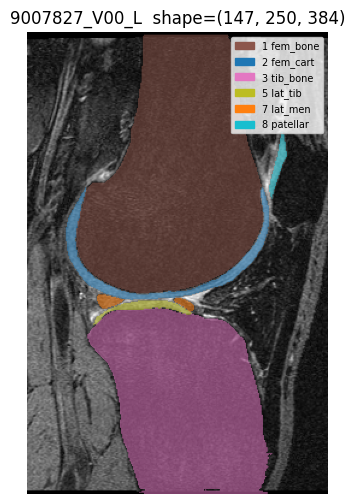

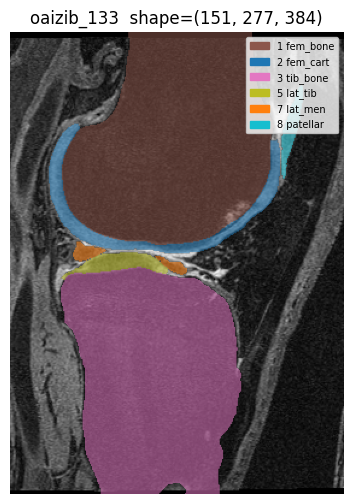

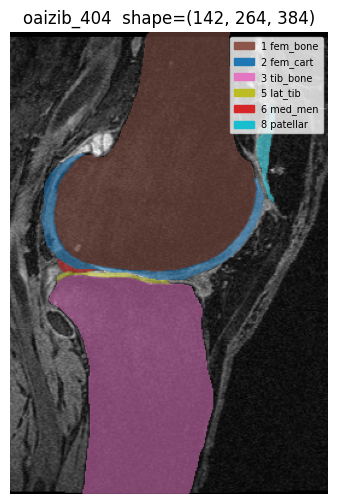

In [ ]:
import numpy as np, nibabel as nib, matplotlib.pyplot as plt, matplotlib.colors as mcolors
from matplotlib.patches import Patch
from pathlib import Path

NM={1:"fem_bone",2:"fem_cart",3:"tib_bone",4:"med_tib",5:"lat_tib",6:"med_men",7:"lat_men",8:"patellar"}
COL={1:"#8c564b",2:"#1f77b4",3:"#e377c2",4:"#2ca02c",5:"#bcbd22",6:"#d62728",7:"#ff7f0e",8:"#17becf"}
def show(cid):
    img=np.asanyarray(nib.load(str(D21/"imagesTr"/f"{cid}_0000.nii.gz")).dataobj).astype(float)
    lab=np.asanyarray(nib.load(str(D21/"labelsTr"/f"{cid}.nii.gz")).dataobj).astype(int)
    best=(-1,0,0)
    for ax in range(3):
        cc=(lab>0).sum(axis=tuple(i for i in range(3) if i!=ax))
        if cc.max()>best[0]: best=(cc.max(),ax,int(cc.argmax()))
    ax,z=best[1],best[2]
    ims=np.take(img,z,ax); lbs=np.take(lab,z,ax)
    ims=(ims-ims.min())/(np.ptp(ims)+1e-6); pres=[int(l) for l in np.unique(lbs) if l]
    plt.figure(figsize=(6,6)); plt.imshow(ims.T,cmap="gray",origin="lower")
    rgba=np.zeros(lbs.shape+(4,))
    for l in pres:
        m=lbs==l; rgba[m,:3]=mcolors.to_rgb(COL[l]); rgba[m,3]=0.55
    plt.imshow(np.transpose(rgba,(1,0,2)),origin="lower")
    plt.legend(handles=[Patch(color=COL[l],label=f"{l} {NM[l]}") for l in pres],loc="upper right",fontsize=7)
    plt.title(f"{cid}  shape={lab.shape}"); plt.axis("off"); plt.show()

cs=sorted(p.name.replace(".nii.gz","") for p in (D21/"labelsTr").glob("*.nii.gz"))
for cid in [cs[0], cs[len(cs)//2], cs[-1]]:
    show(cid)


## 4) plan_and_preprocess (ResEnc-L) + xem ROI đổi plan thế nào


In [ ]:
!nnUNetv2_plan_and_preprocess -d 21 -pl nnUNetPlannerResEncL --verify_dataset_integrity


Fingerprint extraction...
Dataset021_CartROI
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer
Extracting dataset fingerprint: 100% 544/544 [00:18<00:00, 29.96it/s]
Experiment planning...
Dropping 3d_lowres config because the image size difference to 3d_fullres is too small. 3d_fullres: [147. 382. 268.], 3d_lowres: [147, 382, 268]
2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 74, 'patch_size': (np.int64(384), np.int64(320)), 'median_image_size_in_voxels': array([382., 268.]), 'spacing': array([0.36458334, 0.36458334]), 'normalization_schemes': ['ZScoreNormalization'], 'use_mask_for_norm': [False], 'resampling_fn_data': 'resample_data_or_seg_to_sh

In [ ]:
import json
pj = json.load(open("/content/nnUNet_preprocessed/Dataset021_CartROI/nnUNetResEncUNetLPlans.json"))
c = pj["configurations"]["3d_fullres"]
print("d21 (ROI) spacing:", c["spacing"], "| patch:", c["patch_size"], "| median voxel:", c["median_image_size_in_voxels"])
print("d20 (full)       : spacing [0.7,0.365,0.365] | patch [80,192,160] | median [160,382,382]")
print("\n-> Neu patch phu ty le lon hon cua ROI (median nho hon) thi sun duoc 'nhin' day hon.")


d21 (ROI) spacing: [0.699999988079071, 0.3645833432674408, 0.3645833432674408] | patch: [112, 288, 224] | median voxel: [147.0, 382.0, 268.0]
d20 (full)       : spacing [0.7,0.365,0.365] | patch [80,192,160] | median [160,382,382]

-> Neu patch phu ty le lon hon cua ROI (median nho hon) thi sun duoc 'nhin' day hon.


## 5) Train Stage-2 fold 0 (ResEnc-L, 250 epoch)

Colab đứt → chạy lại **đúng lệnh + `--c`** để resume (checkpoint ở Drive `nnUNet_results/Dataset021_CartROI`).


In [ ]:
!nnUNetv2_train 21 3d_fullres 0 -p nnUNetResEncUNetLPlans -tr nnUNetTrainer_250epochs


Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2026-07-08 07:37:39.681817: Using torch.compile...
2026-07-08 07:37:41.267797: do_dummy_2d_data_aug: False
2026-07-08 07:37:41.270302: Creating new 5-fold cross-validation split...
2026-07-08 07:37:41.272631: Desired fold for training: 0
2026-07-08 07:37:41.273343: This split has 435 training and 109 validation cases.
using pin_memory on device 0
using pin_memory on device 0

This is the configuration used by this training:
Configuration name: 3d_fullres
 {'data_identifier': 'nnUNetPlans_3d_fullres', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 2, 'patch_si

In [ ]:
!nnUNetv2_train 21 3d_fullres 0 -p nnUNetResEncUNetLPlans -tr nnUNetTrainer_250epochs --c

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2026-07-08 14:18:28.291151: Using torch.compile...
2026-07-08 14:18:58.136482: do_dummy_2d_data_aug: False
2026-07-08 14:18:58.138716: Creating new 5-fold cross-validation split...
2026-07-08 14:18:58.141062: Desired fold for training: 0
2026-07-08 14:18:58.141922: This split has 435 training and 109 validation cases.
using pin_memory on device 0
using pin_memory on device 0

This is the configuration used by this training:
Configuration name: 3d_fullres
 {'data_identifier': 'nnUNetPlans_3d_fullres', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 2, 'patch_si

## 6) CỔNG GT-bbox — eval trong không gian ROI

Vì bbox bao **mọi** foreground GT (+margin), toàn bộ sụn GT nằm trong crop → **Dice/surface trong ROI = trong full-size** cho các lớp này (không cần paste-back ở cổng này).

Bước: crop mỗi ca test (ZIB Ts / iMorph test) bằng **GT-bbox** → predict d21 → so **cropped pred vs cropped GT** (chỉ 2,4,5,6,7,8).


In [ ]:
import SimpleITK as sitk, numpy as np
from pathlib import Path

def build_roi_test(img_dir, lbl_dir, out, key):
    (Path(out)/"img").mkdir(parents=True, exist_ok=True)
    (Path(out)/"gt").mkdir(parents=True, exist_ok=True)
    cases = sorted(p.name.replace(".nii.gz","") for p in Path(lbl_dir).glob("*.nii.gz"))
    for c in cases:
        im = sitk.ReadImage(str(Path(img_dir)/f"{c}_0000.nii.gz"))
        lb = sitk.ReadImage(str(Path(lbl_dir)/f"{c}.nii.gz"))
        lo, hi = bbox_fg(sitk.GetArrayFromImage(lb), margin_vox(im))
        imc, lbc = crop(im, lo, hi), crop(lb, lo, hi); lbc.CopyInformation(imc)
        sitk.WriteImage(imc, str(Path(out)/"img"/f"{c}_0000.nii.gz"))
        sitk.WriteImage(lbc, str(Path(out)/"gt"/f"{c}.nii.gz"))
    print(f"{key}: cropped {len(cases)} ca -> {out}")

build_roi_test(ZIB/"imagesTs", ZIB/"labelsTs", "/content/roi_gt_zib_ts",  "zib_ts")
build_roi_test(IMO/"imagesTs", IMO/"labelsTs", "/content/roi_gt_imo_test", "imo_test")


zib_ts: cropped 103 ca -> /content/roi_gt_zib_ts
imo_test: cropped 36 ca -> /content/roi_gt_imo_test


In [ ]:
!nnUNetv2_predict -i /content/roi_gt_zib_ts/img  -o /content/pred_roi_gtbbox_zib_ts  -d 21 -c 3d_fullres -p nnUNetResEncUNetLPlans -tr nnUNetTrainer_250epochs -f 0 -chk checkpoint_final.pth
!nnUNetv2_predict -i /content/roi_gt_imo_test/img -o /content/pred_roi_gtbbox_imo_test -d 21 -c 3d_fullres -p nnUNetResEncUNetLPlans -tr nnUNetTrainer_250epochs -f 0 -chk checkpoint_final.pth



#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

There are 103 cases in the source folder
I am process 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 103 cases that I would like to predict

Predicting oaizib_405:
perform_everything_on_device: True
100% 8/8 [00:11<00:00,  1.42s/it]
sending off prediction to background worker for resampling and export
done with oaizib_405

Predicting oaizib_406:
perform_everything_on_device: True
100% 8/8 [00:04<00:00,  1.94it/s]
sending off prediction to background worker for resampling and export
done with oaizib_406

Predicting oaizib_407:
perform_everything_on_device: True
100% 8/

In [ ]:
try:
    from surface_distance import metrics as sd; HAVE_SD = True
except Exception: HAVE_SD = False
import numpy as np, SimpleITK as sitk
from pathlib import Path
from collections import defaultdict

def eval_case(gt, pr, classes):
    g = sitk.ReadImage(str(gt)); p = sitk.ReadImage(str(pr)); sp = g.GetSpacing()[::-1]
    ga = sitk.GetArrayFromImage(g).astype(np.int16); pa = sitk.GetArrayFromImage(p).astype(np.int16)
    o = {}
    for c in classes:
        gm, pm = ga == c, pa == c
        if gm.sum() == 0: continue
        d = 2*(gm & pm).sum() / (gm.sum() + pm.sum() + 1e-8)
        if pm.sum() == 0 or not HAVE_SD: o[c] = (d, np.nan, np.nan); continue
        s = sd.compute_surface_distances(gm, pm, spacing_mm=sp); a, b = sd.compute_average_surface_distance(s)
        o[c] = (d, (a+b)/2, sd.compute_robust_hausdorff(s, 95))
    return o

NM = {2:"femoral_cart",4:"med_tib_cart",5:"lat_tib_cart",6:"med_meniscus",7:"lat_meniscus",8:"patellar_cart"}
D20REF = {"zib_ts":  {2:0.891,4:0.852,5:0.868},
          "imo_test":{2:0.868,4:0.851,5:0.902,6:0.859,7:0.900,8:0.859}}
gate_pass = False
for key, gtdir, preddir in [("zib_ts","/content/roi_gt_zib_ts/gt","/content/pred_roi_gtbbox_zib_ts"),
                            ("imo_test","/content/roi_gt_imo_test/gt","/content/pred_roi_gtbbox_imo_test")]:
    acc = defaultdict(lambda: {"d":[],"a":[],"h":[]})
    for f in sorted(Path(gtdir).glob("*.nii.gz")):
        pr = Path(preddir)/f.name
        if not pr.exists(): continue
        for c,(d,a,h) in eval_case(f, pr, REPORT[key]).items():
            acc[c]["d"].append(d)
            if not np.isnan(a): acc[c]["a"].append(a); acc[c]["h"].append(h)
    print("\n" + "="*66 + f"\n{key}  |  ROI cascade d21 (GT-bbox)  vs  d20 single-stage\n" + "="*66)
    print(f"{'class':16s}{'Dice':>8}{'ASSD':>7}{'HD95':>7}{'d20':>8}{'delta':>8}")
    for c in REPORT[key]:
        if c not in acc or not acc[c]["d"]: continue
        d = np.mean(acc[c]["d"]); a = np.mean(acc[c]["a"]) if acc[c]["a"] else float("nan"); h = np.mean(acc[c]["h"]) if acc[c]["h"] else float("nan")
        ref = D20REF[key].get(c); delta = (d-ref) if ref else None
        if c in (4,5) and delta is not None and delta > 0.005: gate_pass = True
        ds = f"{delta:+.3f}" if delta is not None else "-"
        print(f"{NM[c]:16s}{d:8.3f}{a:7.2f}{h:7.2f}{(ref or 0):8.3f}{ds:>8}")
print("\n" + "-"*66)
print("GATE:", "QUA - sun chay tang > +0.005 -> dang dung pipeline pred-bbox (muc 7)." if gate_pass
       else "CHUA QUA - GT-bbox (tran tren) khong nang sun chay. Xem ablation, hoac giu d20.")



zib_ts  |  ROI cascade d21 (GT-bbox)  vs  d20 single-stage
class               Dice   ASSD   HD95     d20   delta
femoral_cart       0.890    nan    nan   0.891  -0.001
med_tib_cart       0.853    nan    nan   0.852  +0.001
lat_tib_cart       0.869    nan    nan   0.868  +0.001

imo_test  |  ROI cascade d21 (GT-bbox)  vs  d20 single-stage
class               Dice   ASSD   HD95     d20   delta
femoral_cart       0.871    nan    nan   0.868  +0.003
med_tib_cart       0.852    nan    nan   0.851  +0.001
lat_tib_cart       0.899    nan    nan   0.902  -0.003
med_meniscus       0.860    nan    nan   0.859  +0.001
lat_meniscus       0.899    nan    nan   0.900  -0.001
patellar_cart      0.857    nan    nan   0.859  -0.002

------------------------------------------------------------------
GATE: CHUA QUA - GT-bbox (tran tren) khong nang sun chay. Xem ablation, hoac giu d20.


## 7) (TÙY CHỌN) pred-bbox end-to-end — CHỈ chạy sau khi qua cổng mục 6

Thực tế triển khai: bbox lấy từ **pred của d20** (Stage-1), không phải GT. Cần **paste-back** về full-size (pred-bbox có thể không bao trọn GT).

`Stage-1 = d20` chạy ra pred đầy đủ → bbox foreground pred → crop → d21 → paste vào volume gốc → eval vs GT full. Ghi vào folder MỚI, không đụng pred cũ.


In [ ]:
# --- Stage-1: d20 predict de LAY BBOX (ghi folder moi, khong dung /content/pred_zib_ts cu) ---
!nnUNetv2_predict -i {ZIB}/imagesTs -o /content/pred_stage1_zib_ts  -d 20 -c 3d_fullres -p nnUNetResEncUNetLPlans -tr nnUNetTrainer_250epochs -f 0 -chk checkpoint_final.pth --disable_tta
!nnUNetv2_predict -i {IMO}/imagesTs -o /content/pred_stage1_imo_test -d 20 -c 3d_fullres -p nnUNetResEncUNetLPlans -tr nnUNetTrainer_250epochs -f 0 -chk checkpoint_final.pth --disable_tta


In [ ]:
import SimpleITK as sitk, numpy as np, os
from pathlib import Path
from collections import defaultdict

def paste_full(pred_crop, ref_full, lo, hi):
    arr = np.zeros(sitk.GetArrayFromImage(ref_full).shape, np.uint8)
    arr[lo[0]:hi[0], lo[1]:hi[1], lo[2]:hi[2]] = sitk.GetArrayFromImage(pred_crop)
    out = sitk.GetImageFromArray(arr); out.CopyInformation(ref_full); return out

def run_predbbox(img_dir, lbl_dir, stage1_dir, key):
    tmp_in = f"/content/roi_pred_{key}/img"; Path(tmp_in).mkdir(parents=True, exist_ok=True)
    bb = {}
    cases = sorted(p.name.replace(".nii.gz","") for p in Path(lbl_dir).glob("*.nii.gz"))
    for c in cases:
        im = sitk.ReadImage(str(Path(img_dir)/f"{c}_0000.nii.gz"))
        s1 = sitk.ReadImage(str(Path(stage1_dir)/f"{c}.nii.gz"))
        lo, hi = bbox_fg(sitk.GetArrayFromImage(s1), margin_vox(im))     # bbox tu PRED d20
        sitk.WriteImage(crop(im, lo, hi), f"{tmp_in}/{c}_0000.nii.gz"); bb[c] = (lo, hi)
    out = f"/content/pred_roi_predbbox_{key}"
    os.system(f"nnUNetv2_predict -i {tmp_in} -o {out} -d 21 -c 3d_fullres -p nnUNetResEncUNetLPlans -tr nnUNetTrainer_250epochs -f 0 -chk checkpoint_final.pth")
    # paste-back ve full-size roi eval vs GT goc
    acc = defaultdict(lambda: {"d":[],"a":[],"h":[]})
    for c in cases:
        gt = sitk.ReadImage(str(Path(lbl_dir)/f"{c}.nii.gz"))
        pc = sitk.ReadImage(f"{out}/{c}.nii.gz")
        lo, hi = bb[c]; full = paste_full(pc, gt, lo, hi)
        fp = f"{out}/{c}_full.nii.gz"; sitk.WriteImage(full, fp)
        for cl,(d,a,h) in eval_case(Path(lbl_dir)/f"{c}.nii.gz", fp, REPORT[key]).items():
            acc[cl]["d"].append(d)
            if not np.isnan(a): acc[cl]["a"].append(a); acc[cl]["h"].append(h)
    print("\n" + "="*66 + f"\n{key}  |  ROI cascade d21 (PRED-bbox, end-to-end)  vs  d20\n" + "="*66)
    print(f"{'class':16s}{'Dice':>8}{'ASSD':>7}{'HD95':>7}{'d20':>8}{'delta':>8}")
    for cl in REPORT[key]:
        if cl not in acc or not acc[cl]["d"]: continue
        d = np.mean(acc[cl]["d"]); a = np.mean(acc[cl]["a"]) if acc[cl]["a"] else float("nan"); h = np.mean(acc[cl]["h"]) if acc[cl]["h"] else float("nan")
        ref = D20REF[key].get(cl); ds = f"{d-ref:+.3f}" if ref else "-"
        print(f"{NM[cl]:16s}{d:8.3f}{a:7.2f}{h:7.2f}{(ref or 0):8.3f}{ds:>8}")

run_predbbox(ZIB/"imagesTs", ZIB/"labelsTs", "/content/pred_stage1_zib_ts",  "zib_ts")
run_predbbox(IMO/"imagesTs", IMO/"labelsTs", "/content/pred_stage1_imo_test", "imo_test")


## Kết luận (đọc sau khi có 2 bảng)
- **GT-bbox (mục 6)** = trần trên. Nếu sụn chày (4,5) không vượt d20 ở đây → ROI-crop **không giúp**; cân nhắc ablation (isotropic 0.365 / Focal Tversky / oversample sụn) hoặc **giữ d20**.
- **pred-bbox (mục 7)** = thực tế end-to-end; thường thấp hơn GT-bbox chút (lệch FOV — R2). Chênh lệch lớn → thêm jitter khi train hoặc sinh bbox train từ pred d20.
- Mọi thứ ghi vào **ID/folder mới** → kết quả d20 cũ **nguyên vẹn** để dùng lại.
